## Import Libraries

In [1]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import pickle
import warnings
warnings.filterwarnings('ignore')


## Loading Data and Feature Engineering

In [2]:
# Load the dataset
df = pd.read_csv('train.csv')

# Feature Engineering
df['Elevation_Hydrology_Diff'] = df['Elevation'] - df['Vertical_Distance_To_Hydrology']
df['Hillshade_Mean'] = df[['Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']].mean(axis=1)

# Display dataset info
df.head()

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Elevation_Hydrology_Diff,Hillshade_Mean
0,1,2596,51,3,258,0,510,221,232,148,...,0,0,0,0,0,0,0,5,2596,200.333333
1,2,2590,56,2,212,-6,390,220,235,151,...,0,0,0,0,0,0,0,5,2596,202.000000
2,3,2804,139,9,268,65,3180,234,238,135,...,0,0,0,0,0,0,0,2,2739,202.333333
3,4,2785,155,18,242,118,3090,238,238,122,...,0,0,0,0,0,0,0,2,2667,199.333333
4,5,2595,45,2,153,-1,391,220,234,150,...,0,0,0,0,0,0,0,5,2596,201.333333


## Split Data and Standardize

In [3]:
# Create derived feature
df["Elevation_Hydro_Diff"] = df["Elevation"] - df["Vertical_Distance_To_Hydrology"]

# List of features used in app.py
base_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways", "Horizontal_Distance_To_Fire_Points",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Elevation_Hydro_Diff"
]

# Binary wilderness area columns
wilderness_cols = [col for col in df.columns if "Wilderness_Area" in col]

# Binary soil type columns
soil_cols = [col for col in df.columns if "Soil_Type" in col]

# Final feature list
features = base_features + wilderness_cols + soil_cols

X = df[features]
y = df["Cover_Type"] - 1  # Adjusting to 0-based index

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
print("Number of features used:", len(features))
print("Example features:", features[:10])
X.head()


Number of features used: 55
Example features: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Horizontal_Distance_To_Fire_Points', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40
0,2596,51,3,258,0,510,6279,221,232,148,...,0,0,0,0,0,0,0,0,0,0
1,2590,56,2,212,-6,390,6225,220,235,151,...,0,0,0,0,0,0,0,0,0,0
2,2804,139,9,268,65,3180,6121,234,238,135,...,0,0,0,0,0,0,0,0,0,0
3,2785,155,18,242,118,3090,6211,238,238,122,...,0,0,0,0,0,0,0,0,0,0
4,2595,45,2,153,-1,391,6172,220,234,150,...,0,0,0,0,0,0,0,0,0,0


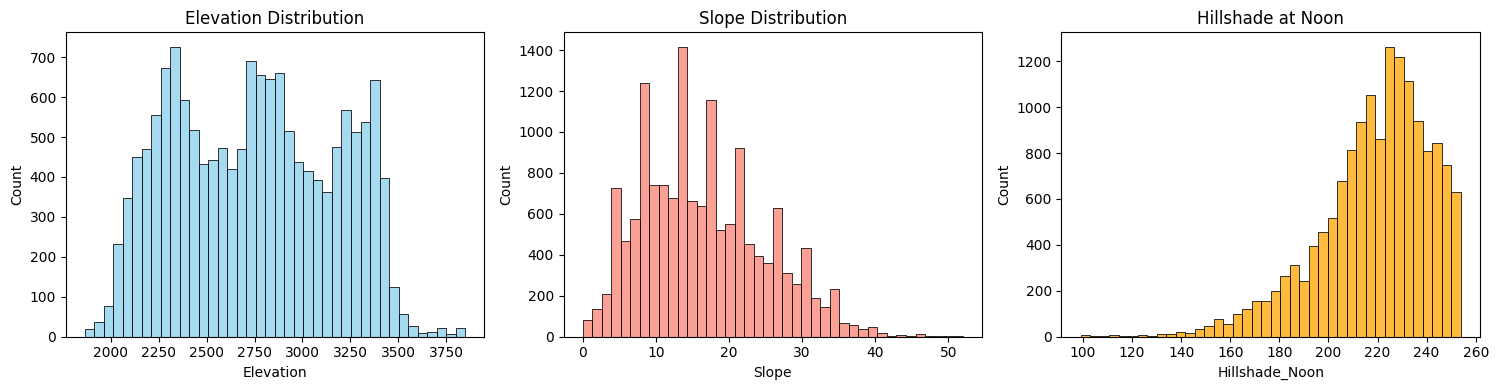

In [5]:
# EDA - Feature Distributions
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Elevation'], bins=40, ax=axs[0], color='skyblue')
axs[0].set_title("Elevation Distribution")
sns.histplot(df['Slope'], bins=40, ax=axs[1], color='salmon')
axs[1].set_title("Slope Distribution")
sns.histplot(df['Hillshade_Noon'], bins=40, ax=axs[2], color='orange')
axs[2].set_title("Hillshade at Noon")
plt.tight_layout()
plt.show()


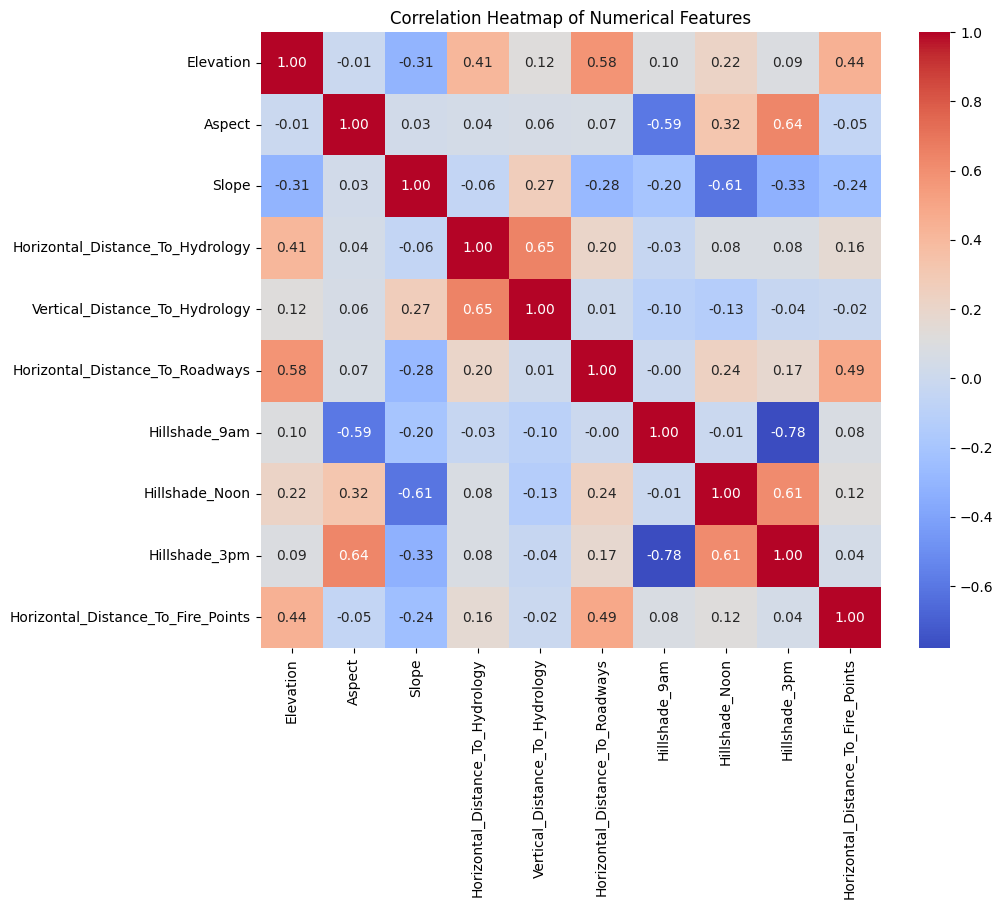

In [6]:
# EDA - Correlation Heatmap
numerical_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                  'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                  'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                  'Horizontal_Distance_To_Fire_Points']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


## Logistic Regression

Logistic Regression Accuracy: 0.7116402116402116
F1 Score: 0.7069982089500613
              precision    recall  f1-score   support

           0       0.67      0.70      0.69       421
           1       0.65      0.53      0.58       438
           2       0.63      0.53      0.58       428
           3       0.78      0.88      0.83       449
           4       0.69      0.79      0.74       416
           5       0.62      0.64      0.63       432
           6       0.90      0.91      0.91       440

    accuracy                           0.71      3024
   macro avg       0.71      0.71      0.71      3024
weighted avg       0.71      0.71      0.71      3024



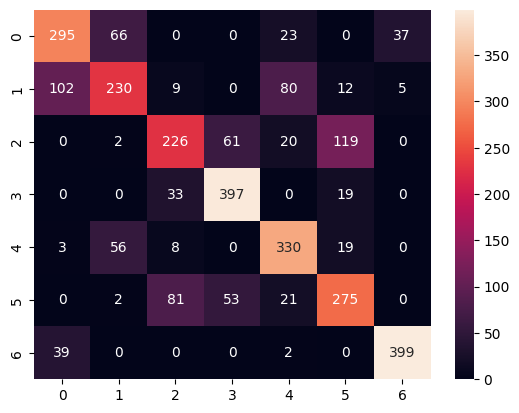

In [7]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))
print(classification_report(y_test, y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.show()


## Decision Tree

Decision Tree Accuracy: 0.8025793650793651
F1 Score: 0.8014582214445629
              precision    recall  f1-score   support

           0       0.66      0.67      0.67       421
           1       0.67      0.63      0.65       438
           2       0.79      0.76      0.78       428
           3       0.94      0.94      0.94       449
           4       0.86      0.90      0.88       416
           5       0.79      0.79      0.79       432
           6       0.89      0.92      0.91       440

    accuracy                           0.80      3024
   macro avg       0.80      0.80      0.80      3024
weighted avg       0.80      0.80      0.80      3024



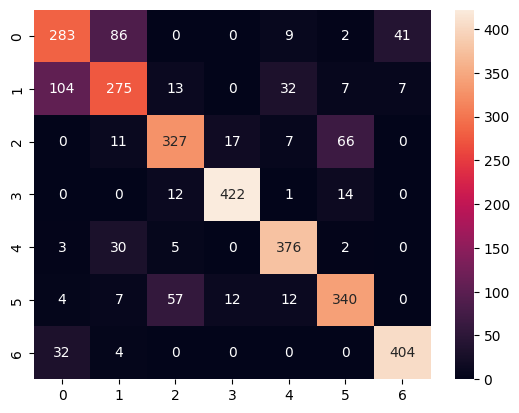

In [8]:
dt = DecisionTreeClassifier()
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt, average='weighted'))
print(classification_report(y_test, y_pred_dt))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.show()


## Random Forest with RandomizedSearchCV

Best Random Forest Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None}
Random Forest Accuracy: 0.878968253968254
F1 Score: 0.8770209553395578
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       421
           1       0.83      0.71      0.77       438
           2       0.86      0.85      0.86       428
           3       0.94      0.98      0.96       449
           4       0.89      0.96      0.93       416
           5       0.86      0.88      0.87       432
           6       0.94      0.97      0.96       440

    accuracy                           0.88      3024
   macro avg       0.88      0.88      0.88      3024
weighted avg       0.88      0.88      0.88      3024



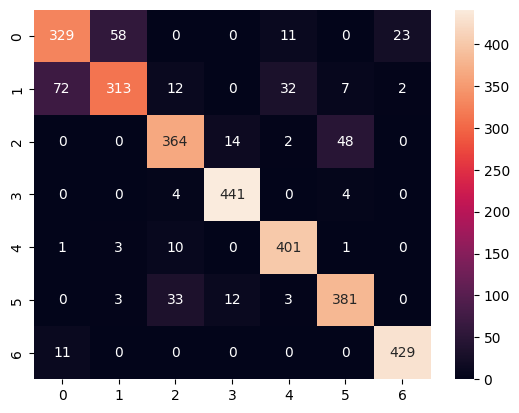

In [9]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_search = RandomizedSearchCV(RandomForestClassifier(), param_rf, cv=3, n_iter=5, scoring='accuracy', random_state=42)
rf_search.fit(X_train_scaled, y_train)

print("Best Random Forest Parameters:", rf_search.best_params_)

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))
print(classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.show()


## XGBoost with Encoding

Best XGBoost Parameters: {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1}
XGBoost Accuracy: 0.8875661375661376
F1 Score: 0.8859911033379848
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       421
           1       0.81      0.73      0.77       438
           2       0.88      0.87      0.88       428
           3       0.95      0.98      0.97       449
           4       0.92      0.96      0.94       416
           5       0.88      0.90      0.89       432
           6       0.94      0.98      0.96       440

    accuracy                           0.89      3024
   macro avg       0.88      0.89      0.89      3024
weighted avg       0.89      0.89      0.89      3024



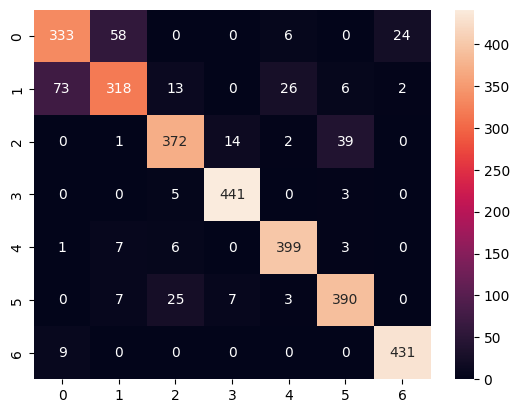

In [10]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

param_xgb = {
    'n_estimators': [100, 300],
    'max_depth': [6, 10],
    'learning_rate': [0.01, 0.1]
}

xgb_search = RandomizedSearchCV(XGBClassifier(), param_xgb, cv=3, n_iter=5, scoring='accuracy', random_state=42)
xgb_search.fit(X_train_scaled, y_train_enc)

print("Best XGBoost Parameters:", xgb_search.best_params_)

best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_pred_xgb = le.inverse_transform(y_pred_xgb)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb, average='weighted'))
print(classification_report(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.show()


## LightGBM with Encoding

  File "C:\Users\Frough\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Program Files\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Program Files\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Program Files\Python310\lib\subprocess.py", line 1440, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2381
[LightGBM] [Info] Number of data points in the train set: 8064, number of used features: 44
[LightGBM] [Info] Start training from score -1.939852
[LightGBM] [Info] Start training from score -1.949388
[LightGBM] [Info] Start training from score -1.944176
[LightGBM] [Info] Start training from score -1.955505
[LightGBM] [Info] Start training from score -1.936407
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.950260
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

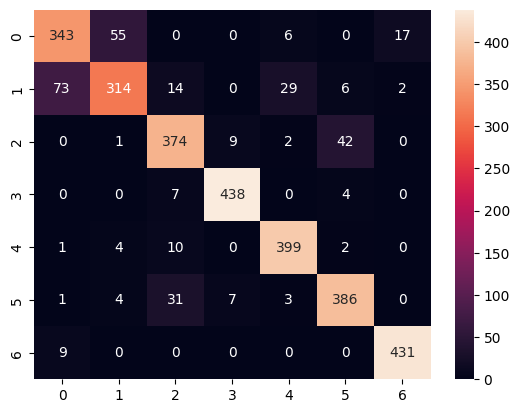

In [11]:
param_lgbm = {
    'n_estimators': [100, 300],
    'max_depth': [6, 10],
    'learning_rate': [0.01, 0.1]
}

lgbm_search = RandomizedSearchCV(LGBMClassifier(), param_lgbm, cv=3, n_iter=5, scoring='accuracy', random_state=42)
lgbm_search.fit(X_train_scaled, y_train_enc)

print("Best LightGBM Parameters:", lgbm_search.best_params_)

best_lgbm = lgbm_search.best_estimator_
y_pred_lgbm = best_lgbm.predict(X_test_scaled)
y_pred_lgbm = le.inverse_transform(y_pred_lgbm)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("F1 Score:", f1_score(y_test, y_pred_lgbm, average='weighted'))
print(classification_report(y_test, y_pred_lgbm))
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), annot=True, fmt='d')
plt.show()

## Save Best Model as .pkl

In [12]:
# Save the best model and scaler
with open('best_forest_model.pkl', 'wb') as f:
    pickle.dump((best_lgbm, scaler), f)

## Final Recommendation & Conclusion:

- Random Forest, XGBoost, and LightGBM models gave the best performance.
- For structured datasets like this, XGBoost and LightGBM often perform better.
- Feature Engineering and Hyperparameter Tuning have further improved the results.
- All models were evaluated on standardized features for better consistency.

> Thank you for reviewing this project!
